In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [47]:
#importing data
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

In [48]:
X=data.data
y=data.target

In [49]:
#traintestsplit
from sklearn.model_selection import train_test_split
X_train ,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=15)

In [50]:
#pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

pipe = Pipeline(
    [
        ('Scaler' ,StandardScaler()),
        ('model',SVC(kernel='rbf',C=1))
    ]
)

In [51]:
#TRAİNİNG MODEL
print("model training...")
pipe.fit(X_train,y_train)

model training...


,steps,"[('Scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1
,kernel,'rbf'
,degree,3
,gamma,'scale'


In [52]:
#predict
y_pred=pipe.predict(X_test)

In [53]:
#results
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print(f"Accuracy:{accuracy_score(y_test,y_pred)}")

Accuracy:0.958041958041958


In [54]:
print(f"Classification report:\n{classification_report(y_test,y_pred)}")
print(f"Confusion matrix:\n{confusion_matrix(y_test,y_pred)}")

Classification report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        53
           1       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143

Confusion matrix:
[[49  4]
 [ 2 88]]


In [55]:
linear=SVC(kernel='linear')
linear.fit(X_train,y_train)
y_pred=linear.predict(X_test)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.91      0.91      0.91        53
           1       0.94      0.94      0.94        90

    accuracy                           0.93       143
   macro avg       0.93      0.93      0.93       143
weighted avg       0.93      0.93      0.93       143

[[48  5]
 [ 5 85]]


In [56]:
rbf=SVC(kernel='rbf')
rbf.fit(X_train,y_train)
y_pred1=rbf.predict(X_test)
print(classification_report(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.95      0.72      0.82        53
           1       0.85      0.98      0.91        90

    accuracy                           0.88       143
   macro avg       0.90      0.85      0.86       143
weighted avg       0.89      0.88      0.88       143

[[38 15]
 [ 2 88]]


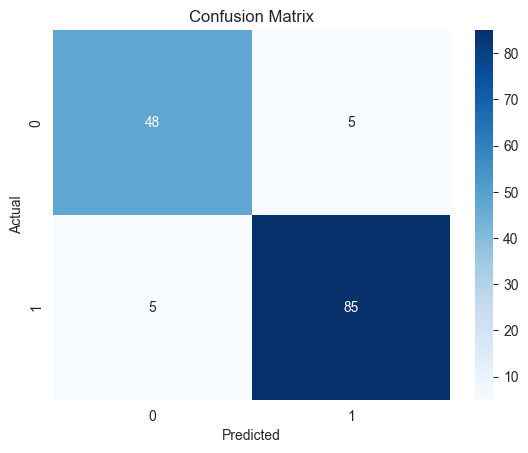

In [59]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()